# Hier-COS Current-Run Trade-Off Plots

This notebook reads seeded Hier-COS output directories from `/scratch/g.saggini1/outputs` and aggregates their independently selected test checkpoints.

Included runs:
- global- and level-softmax no-lex baselines;
- global- and level-softmax coarse-first `orthogonalize_all`;
- global-softmax fine-first `orthogonalize_all` as the available priority-direction reference;
- equal and `kl_leaf` weighting when a completed run is available;
- global- and level-softmax identity-frame no-lex baselines and coarse-first runs when available;
- optional BN+Linear transform ablations, controlled by `INCLUDE_BN_LINEAR`;
- optional dimension-tagged no-lex baselines;
- Aircraft global-softmax `pretrainablation` runs (pretrained/scratch × orthonormal/identity) when completed;
- optional LH-DNN projection-layer runs, including plain, PReLU-derivative (`rho`), dimension-tagged, and advantage variants, controlled by `INCLUDE_LHDNN_PROJECTION`;
- optional non-Hier-COS reference models — H-CAST, HRN, LH-DNN, and HT-CapsNet — controlled by `INCLUDE_BASELINE_MODELS`, plotted off-scale on the trade-off panels so they never rescale the Hier-COS view.

Projection runs come in two architectures. Plain `projection` has the level heads read the transform output directly, so `A = [W_0; ...; W_(l-1)]` is shared by the whole batch. `projection_rho` inserts a shared channel-wise PReLU and uses the LH-DNN form `A[b] = [W_0; ...; W_(l-1)] * rho_prime(k[b])`, making the protected subspace sample-dependent. The two are stored under separate output directories and plotted as separate runs.

`conflict_only` and other transform ablations are intentionally excluded. Points and tables report mean ± sample standard deviation across training seeds. All plots use the independently selected checkpoint from each seed. FPA and level accuracy are higher-is-better; TICE is lower-is-better.

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse, Patch
from matplotlib.text import Text
from matplotlib.transforms import Bbox

plt.style.use('seaborn-v0_8-whitegrid')

OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
SAVE_FIGURES = False
INCLUDE_BN_LINEAR = False
INCLUDE_LHDNN_PROJECTION = False
INCLUDE_BASELINE_MODELS = True
FIGURE_DIR = OUTPUTS_ROOT / 'analysis' / 'hiercos_current_runs'

DATASETS = {
    'cifar100': 'CIFAR-100',
    'cub200': 'CUB-200',
    'aircraft': 'Aircraft',
}

RUN_REQUESTS = [
    # Add runs as: (softmax, weighting, priority, *options).
    # softmax: 'global' or 'level'; weighting: 'equal' or 'kl_leaf';
    # priority: 'no_lex', 'coarse_first', 'fine_first', or 'projection';
    # projection is available only with level softmax; frame: 'orthonormal' or 'identity';
    # Options are order-independent: frame, transform, 'resnet50', a positive feature
    # dimension for no-lex baseline or projection runs, 'rho' and/or 'advantage'
    # for projection runs, and/or a dataset-filter collection.
    # ('global', 'equal', 'no_lex'),
    ('global', 'kl_leaf', 'no_lex'),
    ('global', 'kl_leaf', 'no_lex', 'identity'),
    ('global', 'equal', 'coarse_first'),
    ('global', 'equal', 'coarse_first', 'identity'),
    #('global', 'equal', 'fine_first'),
    ('global', 'kl_leaf', 'coarse_first'),
    #('level', 'kl_leaf', 'no_lex'),
    #('level', 'kl_leaf', 'no_lex', 'identity'),
    #('level', 'kl_leaf', 'no_lex', 'identity', 512),
    #('level', 'equal', 'coarse_first'),
    #('level', 'equal', 'coarse_first', 'identity'),
    # ('level', 'kl_leaf', 'coarse_first'),
    #('global', 'kl_leaf', 'no_lex', 'identity', 'full', 'resnet50', {'cifar100'}),
]

if INCLUDE_BN_LINEAR:
    RUN_REQUESTS.extend([
        ('global', 'equal', 'coarse_first', 'orthonormal', 'bn_linear'),
        ('level', 'equal', 'coarse_first', 'orthonormal', 'bn_linear'),
        ('level', 'equal', 'coarse_first', 'identity', 'bn_linear'),
    ])

if INCLUDE_LHDNN_PROJECTION:
    RUN_REQUESTS.extend([
        #('level', 'equal', 'projection'),
        ('level', 'equal', 'projection', 'identity'),
        ('level', 'kl_leaf', 'projection', 'identity'),
        ('level', 'equal', 'projection', 'identity', 512),
        ('level', 'kl_leaf', 'projection', 'identity', 512),
        # PReLU/rho projection: A includes the sample-specific activation derivative.
        ('level', 'kl_leaf', 'projection', 'identity', 'rho'),
        ('level', 'equal', 'projection', 'identity', 'rho'),
        ('level', 'kl_leaf', 'projection', 'identity', 'rho', 512),
        ('level', 'equal', 'projection', 'identity', 'rho', 512),
        #('level', 'kl_leaf', 'projection', 'identity', 512, 'advantage', {'cub200'}),
    ])

SOFTMAX_SPECS = {
    'global': {'loss': 'global_softmax_ce_reg', 'label': 'Global', 'code': 'G'},
    'level': {'loss': 'level_softmax_ce_reg', 'label': 'Level', 'code': 'L'},
}

LOSS_COLORS = {'Global': '#0072B2', 'Level': '#D55E00'}
MODE_LABELS = {'no_lex': 'No lex', 'coarse_first': 'Coarse-first lex', 'fine_first': 'Fine-first lex', 'projection': 'LH-DNN projection'}
MODE_CODES = {'no_lex': 'N', 'coarse_first': 'C', 'fine_first': 'F', 'projection': 'P'}
WEIGHT_CODES = {'equal': 'E', 'kl_leaf': 'K'}
WEIGHT_LABELS = {'equal': 'Equal', 'kl_leaf': 'kl_leaf'}
TRANSFORM_CODES = {'full': '', 'bn_linear': '/BN-L', 'final_only': '/FO'}
TRANSFORM_LABELS = {'full': 'Full', 'bn_linear': 'BN+Linear', 'final_only': 'Final only'}

# Non-Hier-COS reference models, discovered as `{run_prefix}_{dataset_key}` under OUTPUTS_ROOT.
BASELINE_SPECS = [
    {'key': 'hcast', 'run_prefix': 'hcast', 'label': 'H-CAST'},
    {'key': 'hrn', 'run_prefix': 'hrn', 'label': 'HRN'},
    {'key': 'lhdnn', 'run_prefix': 'lhdnn', 'label': 'LH-DNN'},
    {'key': 'ht_capsnet', 'run_prefix': 'capsnet', 'label': 'HT-CapsNet'},
]

# Chosen to stay distinguishable from the Hier-COS global/level softmax colours.
BASELINE_COLORS = {
    'hcast': '#6A3D9A',
    'hrn': '#33A02C',
    'lhdnn': '#E7298A',
    'ht_capsnet': '#8C564B',
}

# Off-scale layout, all expressed as fractions of the Hier-COS-only axis span.
OFF_SCALE_GUTTER = 0.22       # width of the border strip added on each used side
OFF_SCALE_GROUP_SEP = 0.095   # separation between models pinned to the same corner
OFF_SCALE_SEED_SEP = 0.030    # separation between seeds when both metrics are off-scale

if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [20]:
def load_test_metrics(path):
    with Path(path).open('r', encoding='utf-8') as handle:
        return yaml.safe_load(handle)


def seed_dirs(run_dir):
    candidates = []
    for child in Path(run_dir).iterdir() if Path(run_dir).is_dir() else []:
        if not child.is_dir() or not child.name.startswith('seed_'):
            continue
        try:
            seed = int(child.name.removeprefix('seed_'))
        except ValueError:
            continue
        if (child / 'test_metrics.yaml').is_file():
            candidates.append((seed, child))
    return [path for _, path in sorted(candidates)]


def sample_stats(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan, np.nan
    return float(values.mean()), float(values.std(ddof=1)) if values.size > 1 else np.nan


def run_suffix(mode, weight, frame, transform_mode='full', backbone_variant=None, feature_dim=None, advantage_enabled=False, rho_enabled=False):
    if mode == 'no_lex':
        suffix = f'baseline_{weight}'
        if feature_dim is not None:
            suffix += f'_d{feature_dim}'
    elif mode == 'projection':
        suffix = 'projection_rho' if rho_enabled else 'projection'
        if feature_dim is not None:
            suffix += f'_d{feature_dim}'
        if weight != 'equal':
            suffix += f'_{weight}'
        if transform_mode != 'full':
            suffix += f'_{transform_mode}'
    else:
        suffix = f'lex_orthogonalize_all_{mode}'
        if transform_mode != 'full':
            suffix += f'_{transform_mode}'
        if weight != 'equal':
            suffix += f'_{weight}'
    if frame == 'identity':
        suffix += '_identity'
    if backbone_variant:
        suffix += f'_{backbone_variant}'
    if advantage_enabled:
        suffix += '_advantage'
    return suffix


def expand_run_request(request):
    softmax, weight, mode, *rest = request
    frame = 'orthonormal'
    transform_mode = 'full'
    backbone_variant = None
    feature_dim = None
    advantage_enabled = False
    rho_enabled = False
    dataset_filter = None
    for option in rest:
        if isinstance(option, str) and option in {'orthonormal', 'identity'}:
            frame = option
        elif isinstance(option, str) and option in TRANSFORM_CODES:
            transform_mode = option
        elif option == 'resnet50':
            backbone_variant = option
        elif isinstance(option, int) and not isinstance(option, bool):
            if option <= 0:
                raise ValueError(f'Feature dimension must be positive, got {option}.')
            if feature_dim is not None:
                raise ValueError(f'Run request contains multiple feature dimensions: {request!r}')
            feature_dim = option
        elif option == 'advantage':
            advantage_enabled = True
        elif option == 'rho':
            rho_enabled = True
        elif isinstance(option, (set, frozenset, list, tuple)):
            if dataset_filter is not None:
                raise ValueError(f'Run request contains multiple dataset filters: {request!r}')
            dataset_filter = set(option)
        elif option is not None:
            raise ValueError(f'Unsupported run-request option {option!r} in {request!r}')
    if feature_dim is not None and mode not in {'no_lex', 'projection'}:
        raise ValueError('A feature dimension can be specified only for no-lex baseline or projection runs.')
    if advantage_enabled and mode != 'projection':
        raise ValueError("The 'advantage' option can be specified only for projection runs.")
    if rho_enabled and mode != 'projection':
        raise ValueError("The 'rho' option can be specified only for projection runs.")
    softmax_spec = SOFTMAX_SPECS[softmax]
    frame_code = '-ID' if frame == 'identity' else ''
    transform_code = TRANSFORM_CODES[transform_mode]
    backbone_code = '/R50' if backbone_variant == 'resnet50' else ''
    dimension_code = f'/D{feature_dim}' if feature_dim is not None else ''
    advantage_code = '/ADV' if advantage_enabled else ''
    rho_code = '/RHO' if rho_enabled else ''
    display_frame = ' identity' if frame == 'identity' else ''
    display_transform = f" {TRANSFORM_LABELS[transform_mode]}" if transform_mode != 'full' else ''
    display_backbone = ' ResNet-50' if backbone_variant == 'resnet50' else ''
    display_dimension = f' d={feature_dim}' if feature_dim is not None else ''
    display_advantage = ' advantage' if advantage_enabled else ''
    mode_label = MODE_LABELS[mode] + (' rho' if rho_enabled else '')
    return {
        'key': '_'.join(
            str(part) for part in (softmax, weight, mode, frame, transform_mode, backbone_variant, f'd{feature_dim}' if feature_dim is not None else None, 'advantage' if advantage_enabled else None, 'rho' if rho_enabled else None)
            if part and part not in {'orthonormal', 'full'}
        ),
        'softmax': softmax,
        'loss': softmax_spec['loss'],
        'loss_label': softmax_spec['label'],
        'loss_code': softmax_spec['code'],
        'weight': weight,
        'weight_label': WEIGHT_LABELS[weight],
        'mode': mode,
        'mode_label': mode_label,
        'frame': frame,
        'transform_mode': transform_mode,
        'backbone_variant': backbone_variant,
        'feature_dim': feature_dim,
        'advantage_enabled': advantage_enabled,
        'rho_enabled': rho_enabled,
        'dataset_filter': dataset_filter,
        'suffix': run_suffix(mode, weight, frame, transform_mode, backbone_variant, feature_dim, advantage_enabled, rho_enabled),
        'short_label': (
            f"{softmax_spec['code']}-{MODE_CODES[mode]} "
            f"[{WEIGHT_CODES[weight]}{frame_code}{transform_code}{backbone_code}{dimension_code}{rho_code}{advantage_code}]"
        ),
        'plot_label': f"{mode_label}{display_frame}{display_transform}{display_backbone}{display_dimension}{display_advantage}",
    }


def pretraining_ablation_spec(pretraining, frame):
    spec = expand_run_request(('global', 'kl_leaf', 'no_lex', frame, {'aircraft'}))
    identity_suffix = '_identity' if frame == 'identity' else ''
    pretraining_code = 'P' if pretraining == 'pretrained' else 'S'
    frame_code = '-ID' if frame == 'identity' else ''
    spec.update({
        'key': f'global_kl_leaf_no_lex_pretrainablation_{pretraining}_{frame}',
        'study': 'pretrainablation',
        'pretraining': pretraining,
        'run_name': (
            'hiercos_aircraft_global_softmax_ce_reg_pretrainablation_'
            f'kl_leaf_{pretraining}{identity_suffix}'
        ),
        'short_label': f'G-N [K-{pretraining_code}{frame_code}]',
        'plot_label': f'Pretraining ablation: {pretraining}' + (' identity' if frame == 'identity' else ''),
    })
    return spec


RUN_SPECS = [expand_run_request(request) for request in RUN_REQUESTS]
RUN_SPECS.extend(
    pretraining_ablation_spec(pretraining, frame)
    for pretraining in ('pretrained', 'scratch')
    for frame in ('orthonormal', 'identity')
)


def discover_rows():
    rows = []
    missing = []
    for dataset_key, dataset_label in DATASETS.items():
        for spec in RUN_SPECS:
            if spec.get('dataset_filter') and dataset_key not in spec['dataset_filter']:
                continue
            run_name = spec.get('run_name', f"hiercos_{dataset_key}_{spec['loss']}_{spec['suffix']}")
            run_dir = OUTPUTS_ROOT / run_name
            completed_seed_dirs = seed_dirs(run_dir)
            if not completed_seed_dirs:
                missing.append((dataset_label, spec['key'], run_name))
                continue

            seed_values = {}
            for seed_dir in completed_seed_dirs:
                seed = int(seed_dir.name.removeprefix('seed_'))
                selected = load_test_metrics(seed_dir / 'test_metrics.yaml')['independent']
                metrics = selected['test_metrics']
                seed_values[seed] = {
                    'best_epoch': float(selected['best_epoch']),
                    'fpa': 100.0 * float(metrics['fpa_independent']),
                    'tice': 100.0 * float(metrics['tice_independent']),
                    **{
                        f'acc_level_{level}': 100.0 * float(metrics[f'acc_level_independent_{level}'])
                        for level in range(3)
                    },
                }
            best_epoch, best_epoch_std = sample_stats([values['best_epoch'] for values in seed_values.values()])
            fpa, fpa_std = sample_stats([values['fpa'] for values in seed_values.values()])
            tice, tice_std = sample_stats([values['tice'] for values in seed_values.values()])
            row = {
                **spec,
                'dataset': dataset_label,
                'dataset_key': dataset_key,
                'run_name': run_name,
                'seeds': sorted(seed_values),
                'seed_values': seed_values,
                'best_epoch': best_epoch,
                'best_epoch_std': best_epoch_std,
                'fpa': fpa,
                'fpa_std': fpa_std,
                'tice': tice,
                'tice_std': tice_std,
            }
            for level in range(3):
                mean, std = sample_stats([values[f'acc_level_{level}'] for values in seed_values.values()])
                row[f'acc_level_{level}'] = mean
                row[f'acc_level_{level}_std'] = std
            rows.append(row)
    return rows, missing


def mark_pareto(rows):
    for dataset in DATASETS.values():
        subset = [row for row in rows if row['dataset'] == dataset]
        for row in subset:
            dominators = [
                other['short_label'] for other in subset if other is not row
                and other['fpa'] >= row['fpa'] and other['tice'] <= row['tice']
                and (other['fpa'] > row['fpa'] or other['tice'] < row['tice'])
            ]
            row['pareto_optimal'] = not dominators
            row['dominated_by'] = dominators
    return rows


def canonical_global_kl_leaf_baseline(row, rows):
    return next((
        candidate for candidate in rows
        if candidate['dataset'] == row['dataset']
        and candidate['loss_label'] == 'Global'
        and candidate['weight'] == 'kl_leaf'
        and candidate['frame'] == 'orthonormal'
        and candidate['mode'] == 'no_lex'
        and candidate['transform_mode'] == 'full'
        and candidate.get('backbone_variant') is None
        and candidate.get('study') is None
    ), None)


def canonical_baseline_pairs(rows):
    pairs = []
    for row in rows:
        baseline = canonical_global_kl_leaf_baseline(row, rows)
        if baseline is not None and row is not baseline:
            pairs.append({'run': row, 'baseline': baseline})
    return pairs


def point_legend_handles():
    return [
        Line2D([], [], color=LOSS_COLORS['Global'], linewidth=4, label='Global softmax'),
        Line2D([], [], color=LOSS_COLORS['Level'], linewidth=4, label='Level softmax'),
        Line2D([], [], color='#555555', marker='o', linestyle='None',
               markersize=8, label='Equal weighting'),
        Line2D([], [], color='#555555', marker='^', linestyle='None',
               markersize=9, label='kl_leaf weighting'),
        Line2D([], [], color='#555555', marker='o', markerfacecolor='none', linestyle='None',
               markersize=9, markeredgewidth=1.6, label='Hollow marker: identity fixed frame'),
        Line2D([], [], color='#555555', marker='.', linestyle='None',
               markersize=6, alpha=0.35, label='Individual seed'),
        Ellipse((0, 0), 1.0, 0.5, facecolor='#777777', edgecolor='#777777',
                alpha=0.15, label='1-SD covariance ellipse'),
    ]


def add_covariance_ellipse(ax, row, color):
    points = np.asarray([
        [values['tice'], values['fpa']]
        for values in row['seed_values'].values()
    ], dtype=float)
    if points.shape[0] < 3:
        return
    covariance = np.cov(points, rowvar=False, ddof=1)
    if covariance.shape != (2, 2) or not np.all(np.isfinite(covariance)):
        return
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    eigenvalues = np.clip(eigenvalues, 0.0, None)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    ellipse = Ellipse(
        (row['tice'], row['fpa']),
        width=2.0 * np.sqrt(eigenvalues[0]),
        height=2.0 * np.sqrt(eigenvalues[1]),
        angle=angle,
        facecolor=color,
        edgecolor=color,
        alpha=0.12,
        linewidth=1.0,
        zorder=2,
    )
    ax.add_patch(ellipse)


def _bbox_overlap_area(first, second):
    width = max(0.0, min(first.x1, second.x1) - max(first.x0, second.x0))
    height = max(0.0, min(first.y1, second.y1) - max(first.y0, second.y0))
    return width * height


def place_point_labels(ax, label_specs, fontsize=8):
    """Place labels greedily in display space and connect them to their points."""
    if not label_specs:
        return

    figure = ax.figure
    figure.canvas.draw()
    renderer = figure.canvas.get_renderer()
    axes_bbox = ax.get_window_extent(renderer=renderer).padded(-3)
    point_pixels = np.asarray([
        ax.transData.transform((spec['x'], spec['y']))
        for spec in label_specs
    ])
    point_boxes = [
        Bbox.from_extents(x - 6, y - 6, x + 6, y + 6)
        for x, y in point_pixels
    ]

    # Dense points are placed first because they have fewer viable label positions.
    distances = np.linalg.norm(point_pixels[:, None, :] - point_pixels[None, :, :], axis=2)
    density = ((distances < 80) & (distances > 0)).sum(axis=1)
    placement_order = sorted(
        range(len(label_specs)),
        key=lambda index: (density[index], len(label_specs[index]['text'])),
        reverse=True,
    )
    candidates = [
        (8, 6), (8, -6), (-8, 6), (-8, -6),
        (18, 0), (-18, 0), (8, 20), (8, -20), (-8, 20), (-8, -20),
        (30, 10), (30, -10), (-30, 10), (-30, -10),
        (14, 34), (14, -34), (-14, 34), (-14, -34),
        (46, 18), (46, -18), (-46, 18), (-46, -18),
        (12, 48), (12, -48), (-12, 48), (-12, -48),
        (36, 34), (36, -34), (-36, 34), (-36, -34),
        (12, 62), (12, -62), (-12, 62), (-12, -62),
        (58, 30), (58, -30), (-58, 30), (-58, -30),
        (16, 78), (16, -78), (-16, 78), (-16, -78),
    ]
    occupied_boxes = []

    for index in placement_order:
        spec = label_specs[index]
        annotation = ax.annotate(
            spec['text'], (spec['x'], spec['y']), xytext=(0, 0),
            textcoords='offset points', fontsize=fontsize, color=spec['color'],
            zorder=5,
            bbox={'boxstyle': 'round,pad=0.15', 'facecolor': 'white',
                  'edgecolor': 'none', 'alpha': 0.82},
            arrowprops={
                'arrowstyle': '-', 'color': spec['color'], 'alpha': 0.55,
                'linewidth': 0.7, 'shrinkA': 2, 'shrinkB': 5,
            },
        )
        best = None
        for rank, (dx, dy) in enumerate(candidates):
            annotation.xyann = (dx, dy)
            annotation.set_horizontalalignment('left' if dx >= 0 else 'right')
            annotation.set_verticalalignment('bottom' if dy > 0 else 'top' if dy < 0 else 'center')
            annotation.update_positions(renderer)
            bbox = Text.get_window_extent(annotation, renderer=renderer).padded(2)

            label_overlap = sum(_bbox_overlap_area(bbox, other) for other in occupied_boxes)
            point_overlap = sum(
                _bbox_overlap_area(bbox, point_box)
                for point_index, point_box in enumerate(point_boxes)
                if point_index != index
            )
            outside = (
                max(0.0, axes_bbox.x0 - bbox.x0) * bbox.height
                + max(0.0, bbox.x1 - axes_bbox.x1) * bbox.height
                + max(0.0, axes_bbox.y0 - bbox.y0) * bbox.width
                + max(0.0, bbox.y1 - axes_bbox.y1) * bbox.width
            )
            distance_penalty = 0.15 * np.hypot(dx, dy) + 0.02 * rank
            score = 1000.0 * label_overlap + 250.0 * point_overlap + 1000.0 * outside + distance_penalty
            if best is None or score < best[0]:
                best = (score, dx, dy, bbox)

        _, dx, dy, bbox = best
        annotation.xyann = (dx, dy)
        annotation.set_horizontalalignment('left' if dx >= 0 else 'right')
        annotation.set_verticalalignment('bottom' if dy > 0 else 'top' if dy < 0 else 'center')
        occupied_boxes.append(bbox)


def save_or_show(fig, filename):
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / filename, bbox_inches='tight')
    plt.show()


rows, missing_runs = discover_rows()
rows = mark_pareto(rows)
for dataset in DATASETS.values():
    available = [row['short_label'] for row in rows if row['dataset'] == dataset]
    print(f'{dataset}: {", ".join(available)}')
print(f'Optional run specifications not found: {len(missing_runs)}')

CIFAR-100: G-N [K], G-N [K-ID], G-C [E], G-C [E-ID], G-C [K]
CUB-200: G-N [K], G-N [K-ID], G-C [E], G-C [E-ID], G-C [K]
Aircraft: G-N [K], G-N [K-ID], G-C [E], G-C [E-ID], G-C [K]
Optional run specifications not found: 4


In [21]:
def load_baseline_seed_values(seed_dir):
    """Read one baseline seed, tolerating the legacy single-selection layout."""
    payload = load_test_metrics(seed_dir / 'test_metrics.yaml')
    # Current runs store separate top-down and independent selections; older
    # baseline runs store a single selection with the same metric keys.
    single_selection = 'independent' not in payload
    selected = payload if single_selection else payload['independent']
    metrics = selected['test_metrics']
    values = {
        'best_epoch': float(selected['best_epoch']) if 'best_epoch' in selected else np.nan,
        'fpa': 100.0 * float(metrics['fpa_independent']),
        'tice': 100.0 * float(metrics['tice_independent']),
        **{
            f'acc_level_{level}': 100.0 * float(metrics[f'acc_level_independent_{level}'])
            for level in range(3)
        },
    }
    return values, single_selection


def discover_baseline_rows():
    rows = []
    missing = []
    for dataset_key, dataset_label in DATASETS.items():
        for spec in BASELINE_SPECS:
            run_name = f"{spec['run_prefix']}_{dataset_key}"
            completed_seed_dirs = seed_dirs(OUTPUTS_ROOT / run_name)
            if not completed_seed_dirs:
                missing.append({'dataset': dataset_label, 'label': spec['label'], 'run_name': run_name})
                continue

            seed_values = {}
            single_selection = False
            for seed_dir in completed_seed_dirs:
                seed = int(seed_dir.name.removeprefix('seed_'))
                seed_values[seed], seed_single = load_baseline_seed_values(seed_dir)
                single_selection = single_selection or seed_single
            fpa, fpa_std = sample_stats([values['fpa'] for values in seed_values.values()])
            tice, tice_std = sample_stats([values['tice'] for values in seed_values.values()])
            best_epoch, best_epoch_std = sample_stats([values['best_epoch'] for values in seed_values.values()])
            row = {
                **spec,
                'dataset': dataset_label,
                'dataset_key': dataset_key,
                'run_name': run_name,
                'color': BASELINE_COLORS[spec['key']],
                'seeds': sorted(seed_values),
                'seed_values': seed_values,
                'single_selection': single_selection,
                'best_epoch': best_epoch,
                'best_epoch_std': best_epoch_std,
                'fpa': fpa,
                'fpa_std': fpa_std,
                'tice': tice,
                'tice_std': tice_std,
            }
            for level in range(3):
                mean, std = sample_stats([values[f'acc_level_{level}'] for values in seed_values.values()])
                row[f'acc_level_{level}'] = mean
                row[f'acc_level_{level}_std'] = std
            rows.append(row)
    return rows, missing


def baseline_display_label(row):
    return row['label'] + ('*' if row['single_selection'] else '')


def baseline_point_label(row):
    """Compact annotation carrying the model name and both off-scale metric values."""
    seed_count = len(row['seeds'])
    header = baseline_display_label(row) + (f' ×{seed_count}' if seed_count > 1 else '')
    if seed_count > 1 and np.isfinite(row['fpa_std']) and np.isfinite(row['tice_std']):
        return (
            f"{header}\nFPA {row['fpa']:.1f} ± {row['fpa_std']:.1f}"
            f"\nTICE {row['tice']:.2f} ± {row['tice_std']:.2f}"
        )
    return f"{header}\nFPA {row['fpa']:.1f}\nTICE {row['tice']:.2f}"


def _off_scale_sign(value, inner_lo, inner_hi):
    if value < inner_lo:
        return -1
    if value > inner_hi:
        return 1
    return 0


def off_scale_layout(baseline_subset, inner_xlim, inner_ylim):
    """Pin off-scale baselines into a border gutter around the Hier-COS axis range.

    Metrics inside the Hier-COS range keep their true coordinate. Metrics outside
    it are pinned to the middle of a gutter added on that side, so the marker sits
    on the border and its position on that axis is only an out-of-range indicator.
    Models sharing a corner are separated along the border, and seeds are fanned
    out only when both metrics are pinned and no real position is left to show.
    """
    x_span = inner_xlim[1] - inner_xlim[0]
    y_span = inner_ylim[1] - inner_ylim[0]

    entries = [
        {
            'row': row,
            'sx': _off_scale_sign(row['tice'], *inner_xlim),
            'sy': _off_scale_sign(row['fpa'], *inner_ylim),
        }
        for row in baseline_subset
    ]
    used_sides = {
        'left': any(entry['sx'] < 0 for entry in entries),
        'right': any(entry['sx'] > 0 for entry in entries),
        'bottom': any(entry['sy'] < 0 for entry in entries),
        'top': any(entry['sy'] > 0 for entry in entries),
    }
    outer_xlim = (
        inner_xlim[0] - (OFF_SCALE_GUTTER * x_span if used_sides['left'] else 0.0),
        inner_xlim[1] + (OFF_SCALE_GUTTER * x_span if used_sides['right'] else 0.0),
    )
    outer_ylim = (
        inner_ylim[0] - (OFF_SCALE_GUTTER * y_span if used_sides['bottom'] else 0.0),
        inner_ylim[1] + (OFF_SCALE_GUTTER * y_span if used_sides['top'] else 0.0),
    )

    def pinned(sign, value, inner, outer):
        if sign < 0:
            return 0.5 * (outer[0] + inner[0])
        if sign > 0:
            return 0.5 * (inner[1] + outer[1])
        return value

    for entry in entries:
        entry['x'] = pinned(entry['sx'], entry['row']['tice'], inner_xlim, outer_xlim)
        entry['y'] = pinned(entry['sy'], entry['row']['fpa'], inner_ylim, outer_ylim)

    # Models pinned to the same corner would coincide, so spread them along the
    # border, i.e. perpendicular to the direction their true value lies in.
    zones = {}
    for entry in entries:
        zones.setdefault((entry['sx'], entry['sy']), []).append(entry)
    for (sx, sy), members in zones.items():
        if len(members) < 2 or (sx == 0 and sy == 0):
            continue
        norm = float(np.hypot(sx, sy))
        perp_x, perp_y = -sy / norm, sx / norm
        for index, entry in enumerate(sorted(members, key=lambda item: item['row']['label'])):
            offset = (index - (len(members) - 1) / 2) * OFF_SCALE_GROUP_SEP
            if sx:
                entry['x'] += offset * perp_x * x_span
            if sy:
                entry['y'] += offset * perp_y * y_span

    for entry in entries:
        sx, sy = entry['sx'], entry['sy']
        seed_points = list(entry['row']['seed_values'].values())
        if sx and sy:
            # Both metrics pinned: no true coordinate survives, so fan the seeds
            # along the border ordered by how far out of range they sit.
            norm = float(np.hypot(sx, sy))
            perp_x, perp_y = -sy / norm, sx / norm
            count = len(seed_points)
            entry['seed_xy'] = [
                (
                    entry['x'] + (index - (count - 1) / 2) * OFF_SCALE_SEED_SEP * perp_x * x_span,
                    entry['y'] + (index - (count - 1) / 2) * OFF_SCALE_SEED_SEP * perp_y * y_span,
                )
                for index in range(count)
            ]
            entry['seed_positions_are_ordinal'] = True
        else:
            entry['seed_xy'] = [
                (entry['x'] if sx else point['tice'], entry['y'] if sy else point['fpa'])
                for point in seed_points
            ]
            entry['seed_positions_are_ordinal'] = False
        # Triangle rotated so its tip points towards the true, off-scale value.
        entry['marker'] = (
            's' if (sx == 0 and sy == 0)
            else (3, 0, float(np.degrees(np.arctan2(sy, sx)) - 90.0))
        )
        entry['off_scale'] = bool(sx or sy)

    return {
        'entries': entries,
        'used_sides': used_sides,
        'outer_xlim': outer_xlim,
        'outer_ylim': outer_ylim,
    }


def draw_off_scale_gutters(ax, inner_xlim, inner_ylim, layout):
    """Shade the border strips holding off-scale points and outline the Hier-COS range."""
    shade = {'facecolor': '#000000', 'alpha': 0.05, 'linewidth': 0, 'zorder': 0}
    boundary = {'color': '#777777', 'linestyle': (0, (4, 3)), 'linewidth': 0.9, 'zorder': 1}
    outer_xlim, outer_ylim = layout['outer_xlim'], layout['outer_ylim']
    if layout['used_sides']['left']:
        ax.axvspan(outer_xlim[0], inner_xlim[0], **shade)
        ax.axvline(inner_xlim[0], **boundary)
    if layout['used_sides']['right']:
        ax.axvspan(inner_xlim[1], outer_xlim[1], **shade)
        ax.axvline(inner_xlim[1], **boundary)
    if layout['used_sides']['bottom']:
        ax.axhspan(outer_ylim[0], inner_ylim[0], **shade)
        ax.axhline(inner_ylim[0], **boundary)
    if layout['used_sides']['top']:
        ax.axhspan(inner_ylim[1], outer_ylim[1], **shade)
        ax.axhline(inner_ylim[1], **boundary)


def baseline_legend_handles(baseline_subset):
    handles = [
        Line2D([], [], color=BASELINE_COLORS[spec['key']], marker='s', linestyle='None',
               markersize=8, label=spec['label'])
        for spec in BASELINE_SPECS
        if any(row['key'] == spec['key'] for row in baseline_subset)
    ]
    if handles:
        handles.extend([
            Line2D([], [], color='#555555', marker=(3, 0, -90), linestyle='None',
                   markersize=11, label='Off-scale: tip points to the true value'),
            Patch(facecolor='#000000', alpha=0.05, edgecolor='#777777', linestyle='--',
                  label='Off-scale gutter (beyond the Hier-COS range)'),
        ])
    return handles


baseline_rows, missing_baseline_runs = discover_baseline_rows()
for dataset in DATASETS.values():
    print(f'\n{dataset}')
    subset = [row for row in baseline_rows if row['dataset'] == dataset]
    for row in sorted(subset, key=lambda item: (-item['fpa'], item['tice'])):
        fpa_text = f"{row['fpa']:.2f}% ± {row['fpa_std']:.2f}" if np.isfinite(row['fpa_std']) else f"{row['fpa']:.2f}%"
        tice_text = f"{row['tice']:.2f}% ± {row['tice_std']:.2f}" if np.isfinite(row['tice_std']) else f"{row['tice']:.2f}%"
        note = ' (single-selection checkpoint)' if row['single_selection'] else ''
        print(
            f"  {baseline_display_label(row):<12} {len(row['seeds']):>2} seeds  "
            f"{fpa_text:<17} {tice_text:<17}{note}"
        )
    for entry in missing_baseline_runs:
        if entry['dataset'] == dataset:
            print(f"  {entry['label']:<12}  no completed test_metrics.yaml under {entry['run_name']}")


CIFAR-100
  H-CAST        3 seeds  73.48% ± 0.19     7.61% ± 0.29     
  LH-DNN        3 seeds  46.14% ± 0.60     17.51% ± 0.47    
  HRN           no completed test_metrics.yaml under hrn_cifar100
  HT-CapsNet    no completed test_metrics.yaml under capsnet_cifar100

CUB-200
  HRN           1 seeds  82.67%            4.83%            
  H-CAST        3 seeds  81.27% ± 0.33     5.24% ± 0.41     
  HT-CapsNet*   1 seeds  25.34%            11.80%            (single-selection checkpoint)
  LH-DNN        3 seeds  2.33% ± 0.23      63.05% ± 1.97    

Aircraft
  HRN           1 seeds  84.54%            6.80%            
  H-CAST        3 seeds  70.73% ± 1.04     9.09% ± 0.10     
  LH-DNN        3 seeds  1.96% ± 0.23      80.71% ± 1.31    
  HT-CapsNet    no completed test_metrics.yaml under capsnet_aircraft


## Independent FPA–TICE Trade-Off

The plot avoids combined shape/fill encodings:
- circles identify equal weighting and triangles identify `kl_leaf` weighting;
- color identifies global versus level softmax;
- hollow markers identify the identity fixed frame;
- collision-aware direct labels identify the priority mode and other run variants;
- thin leader lines keep displaced labels visibly associated with their points.

Higher FPA and lower TICE are preferred.

### Off-scale reference models

`INCLUDE_BASELINE_MODELS` overlays the non-Hier-COS models — H-CAST, HRN, LH-DNN, and HT-CapsNet — without rescaling the Hier-COS view. The axis range is frozen on the Hier-COS runs alone, and a shaded gutter is added only on the sides that a reference model overflows; the dashed line marks the edge of the Hier-COS range.

Reference-model markers are read as follows:

- a metric inside the Hier-COS range keeps its true coordinate;
- a metric outside it is pinned to the middle of the gutter on that side, so the marker's position along that axis carries no magnitude, only the fact that the value is off-scale;
- the marker is a triangle rotated so that its tip points towards where the true value lies; a square marks a reference model that is fully in range;
- the direct label gives the actual FPA and TICE, mean ± sample standard deviation across seeds where more than one seed is available.

Seeds are shown as small hollow triangles. When only one metric is off-scale, the seeds keep their true position along the in-range axis, so their spread is real. When both metrics are off-scale there is no position left to show, so the seeds are fanned along the border by a fixed step purely to keep them countable; the numeric spread in that case lives in the label, not in the geometry. Models pinned to the same corner are separated along the border for the same reason.

A trailing `*` marks a run whose `test_metrics.yaml` predates the split into top-down and independent checkpoint selection, so its checkpoint was selected by a single criterion rather than by the independent criterion used everywhere else. Reference models were trained with their own recipes and epoch budgets and are not weight-matched or schedule-matched to the Hier-COS runs, so they are context for the achievable operating region, not a controlled comparison. They are deliberately excluded from the Pareto analysis below, which stays within the Hier-COS run family.

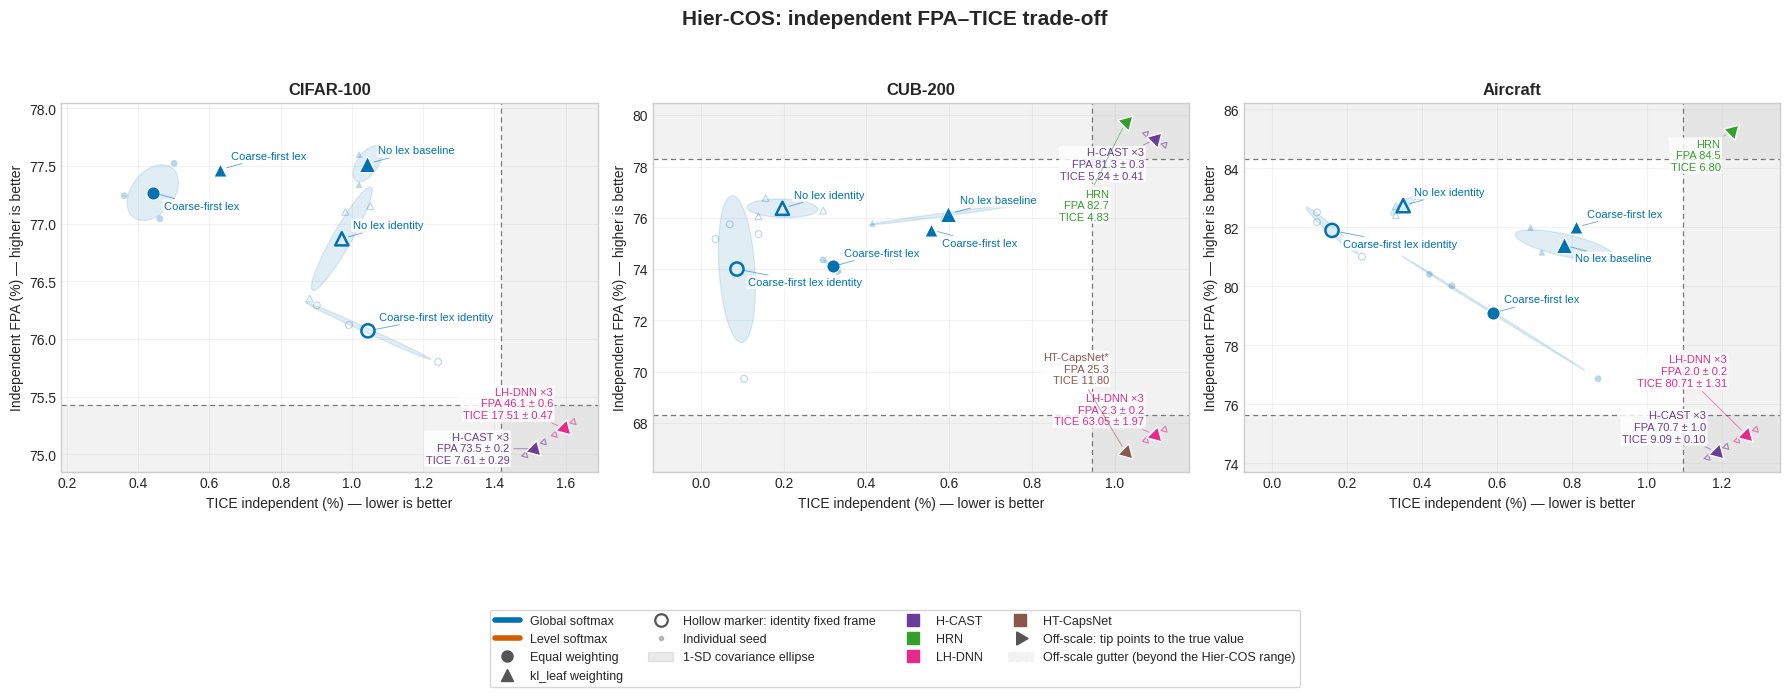

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axis_label_specs = []
plotted_baselines = []
for ax, dataset in zip(axes, DATASETS.values()):
    subset = [row for row in rows if row['dataset'] == dataset]
    label_specs = []

    reference = next(
        row for row in subset
        if row['loss_label'] == 'Global'
        and row['weight'] == 'kl_leaf'
        and row['mode'] == 'no_lex'
        and row.get('study') is None
    )

    for row in subset:
        color = LOSS_COLORS[row['loss_label']]
        marker = 'o' if row['weight'] == 'equal' else '^'
        point_size = 135 if row is reference else 90
        is_identity = row.get('frame') == 'identity'
        seed_points = list(row['seed_values'].values())
        ax.scatter(
            [point['tice'] for point in seed_points],
            [point['fpa'] for point in seed_points],
            marker=marker, s=24, facecolor='none' if is_identity else color,
            edgecolor=color if is_identity else 'none',
            linewidth=0.8 if is_identity else 0, alpha=0.28, zorder=2,
        )
        add_covariance_ellipse(ax, row, color)
        ax.scatter(
            row['tice'], row['fpa'], marker=marker, s=point_size,
            facecolor='none' if is_identity else color,
            edgecolor=color if is_identity else 'white',
            linewidth=1.8 if is_identity else 0.8, zorder=3,
        )
        if row is reference:
            label = 'No lex baseline'
        else:
            label = row['plot_label']
        label_specs.append({
            'x': row['tice'], 'y': row['fpa'], 'text': label, 'color': color,
        })

    # Freeze the axis range on the Hier-COS runs alone before adding any other model.
    ax.margins(x=0.20, y=0.20)
    ax.autoscale_view()
    inner_xlim, inner_ylim = ax.get_xlim(), ax.get_ylim()

    baseline_subset = [row for row in baseline_rows if row['dataset'] == dataset] if INCLUDE_BASELINE_MODELS else []
    layout = off_scale_layout(baseline_subset, inner_xlim, inner_ylim)
    ax.set_xlim(layout['outer_xlim'])
    ax.set_ylim(layout['outer_ylim'])
    draw_off_scale_gutters(ax, inner_xlim, inner_ylim, layout)

    for entry in layout['entries']:
        row = entry['row']
        color = row['color']
        seed_xy = np.asarray(entry['seed_xy'], dtype=float)
        if seed_xy.size:
            ax.scatter(
                seed_xy[:, 0], seed_xy[:, 1], marker=entry['marker'], s=26,
                facecolor='none', edgecolor=color, linewidth=0.9, alpha=0.55, zorder=3,
            )
        ax.scatter(
            entry['x'], entry['y'], marker=entry['marker'], s=170,
            facecolor=color, edgecolor='white', linewidth=1.0, zorder=4,
        )
        label_specs.append({
            'x': entry['x'], 'y': entry['y'],
            'text': baseline_point_label(row), 'color': color,
        })
        plotted_baselines.append(row)

    ax.set_title(dataset, fontweight='bold')
    ax.set_xlabel('TICE independent (%) — lower is better')
    ax.set_ylabel('Independent FPA (%) — higher is better')
    ax.grid(True, alpha=0.25)
    axis_label_specs.append(label_specs)

fig.legend(
    handles=point_legend_handles() + baseline_legend_handles(plotted_baselines),
    loc='lower center', ncol=4,
    bbox_to_anchor=(0.5, -0.16), frameon=True, fontsize=9,
)
fig.suptitle('Hier-COS: independent FPA–TICE trade-off', fontsize=15, fontweight='bold')
fig.tight_layout(rect=(0, 0.12, 1, 0.94))
for ax, label_specs in zip(axes, axis_label_specs):
    place_point_labels(ax, label_specs)
save_or_show(fig, 'fpa_tice_tradeoff_all_softmax.svg')

## Selected-Run Effects Across Hierarchy Levels

Each bar is the independent level-accuracy change of a selected, available run from the canonical no-lex baseline: global-softmax, `kl_leaf`, orthonormal frame, within the same dataset. The baseline itself and runs without a matching baseline are omitted.

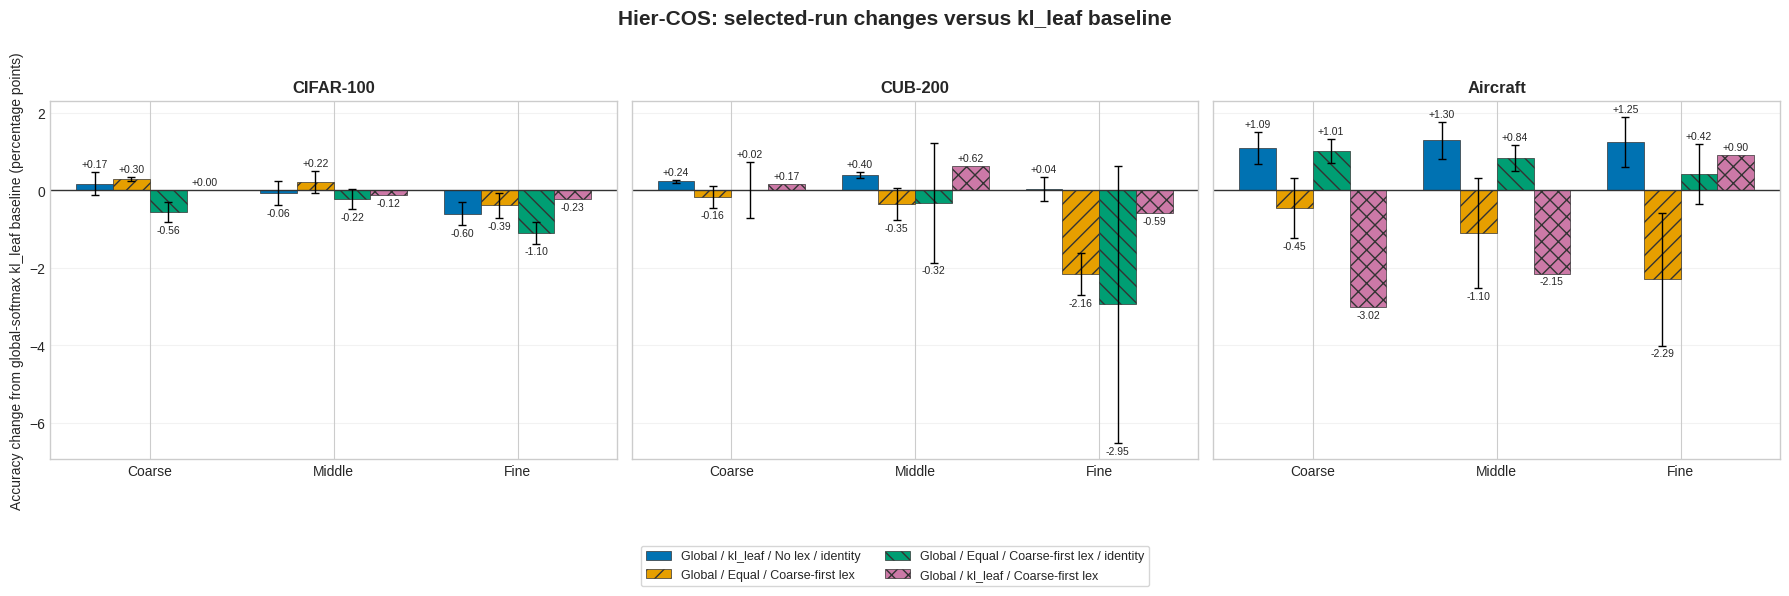

In [23]:
pairs = canonical_baseline_pairs(rows)
bar_colors = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#56B4E9', '#D55E00', '#6A3D9A']
bar_hatches = ['', '//', '\\\\', 'xx', '..', '++', 'oo']


def bar_comparison_label(run):
    parts = [run['loss_label'], run['weight_label'], run['mode_label']]
    if run.get('study') == 'pretrainablation':
        parts.append(f"pretraining ablation: {run['pretraining']}")
    if run['frame'] == 'identity':
        parts.append('identity')
    if run['transform_mode'] != 'full':
        parts.append(TRANSFORM_LABELS[run['transform_mode']])
    if run.get('backbone_variant') == 'resnet50':
        parts.append('ResNet-50')
    if run.get('feature_dim') is not None:
        parts.append(f"d={run['feature_dim']}")
    if run.get('advantage_enabled'):
        parts.append('advantage')
    return ' / '.join(parts)


comparison_keys = list(dict.fromkeys(
    spec['key'] for spec in RUN_SPECS
    if any(pair['run']['key'] == spec['key'] for pair in pairs)
))
comparison_specs = [
    {
        'key': key,
        'label': bar_comparison_label(next(pair['run'] for pair in pairs if pair['run']['key'] == key)),
        'color': bar_colors[index % len(bar_colors)],
        'hatch': bar_hatches[index % len(bar_hatches)],
    }
    for index, key in enumerate(comparison_keys)
]
level_labels = ['Coarse', 'Middle', 'Fine']
x = np.arange(3)
width = min(0.22, 0.8 / max(1, len(comparison_specs)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
for ax, dataset in zip(axes, DATASETS.values()):
    dataset_pairs = [pair for pair in pairs if pair['run']['dataset'] == dataset]
    for index, spec in enumerate(comparison_specs):
        pair = next((
            pair for pair in dataset_pairs
            if pair['run']['key'] == spec['key']
        ), None)
        if pair is None:
            continue
        run, baseline = pair['run'], pair['baseline']
        common_seeds = sorted(set(run['seeds']) & set(baseline['seeds']))
        if not common_seeds:
            continue
        delta_samples = np.asarray([
            [
                run['seed_values'][seed][f'acc_level_{level}']
                - baseline['seed_values'][seed][f'acc_level_{level}']
                for level in range(3)
            ]
            for seed in common_seeds
        ], dtype=float)
        deltas = delta_samples.mean(axis=0)
        delta_stds = delta_samples.std(axis=0, ddof=1) if len(common_seeds) > 1 else np.full(3, np.nan)
        positions = x + (index - (len(comparison_specs) - 1) / 2) * width
        yerr = delta_stds if np.all(np.isfinite(delta_stds)) else None
        bars = ax.bar(
            positions, deltas, width=width, color=spec['color'], hatch=spec['hatch'],
            edgecolor='#333333', linewidth=0.5, label=spec['label'], zorder=2,
            yerr=yerr, capsize=3, error_kw={'linewidth': 1.0},
        )
        ax.bar_label(bars, fmt='%+.2f', fontsize=7.5, padding=2)
    ax.axhline(0, color='#333333', linewidth=1)
    ax.set_title(dataset, fontweight='bold')
    ax.set_xticks(x, level_labels)
    ax.grid(True, axis='y', alpha=0.25)
axes[0].set_ylabel('Accuracy change from global-softmax kl_leaf baseline (percentage points)')
handles = [
    plt.Rectangle(
        (0, 0), 1, 1, facecolor=spec['color'], hatch=spec['hatch'],
        edgecolor='#333333', linewidth=0.5, label=spec['label'],
    )
    for spec in comparison_specs
]
fig.legend(
    handles=handles, loc='lower center', ncol=2,
    bbox_to_anchor=(0.5, -0.08), frameon=True, fontsize=9,
)
fig.suptitle('Hier-COS: selected-run changes versus kl_leaf baseline', fontsize=15, fontweight='bold')
fig.tight_layout(rect=(0, 0.10, 1, 0.94))
save_or_show(fig, 'level_accuracy_matched_lex_deltas.svg')

## Run and Pareto Summary

A point is Pareto-optimal when no available run for the same dataset has both higher-or-equal FPA and lower-or-equal TICE, with at least one strict improvement.

In [24]:
for dataset in DATASETS.values():
    print(f'\n{dataset}')
    print('  code       n   epoch             FPA               TICE              status')
    for row in sorted((r for r in rows if r['dataset'] == dataset), key=lambda r: (-r['fpa'], r['tice'])):
        status = 'Pareto-optimal' if row['pareto_optimal'] else 'dominated by ' + ', '.join(row['dominated_by'])
        epoch_text = f"{row['best_epoch']:.1f} ± {row['best_epoch_std']:.1f}" if np.isfinite(row['best_epoch_std']) else f"{row['best_epoch']:.0f}"
        fpa_text = f"{row['fpa']:.2f}% ± {row['fpa_std']:.2f}" if np.isfinite(row['fpa_std']) else f"{row['fpa']:.2f}%"
        tice_text = f"{row['tice']:.2f}% ± {row['tice_std']:.2f}" if np.isfinite(row['tice_std']) else f"{row['tice']:.2f}%"
        print(
            f"  {row['short_label']:<10} {len(row['seeds']):>2}  {epoch_text:<17} "
            f"{fpa_text:<17} {tice_text:<17} {status}"
        )


CIFAR-100
  code       n   epoch             FPA               TICE              status
  G-N [K]     3  93.7 ± 5.0        77.52% ± 0.16     1.04% ± 0.04      Pareto-optimal
  G-C [K]     1  92                77.47%            0.63%             Pareto-optimal
  G-C [E]     3  97.0 ± 2.0        77.27% ± 0.24     0.44% ± 0.07      Pareto-optimal
  G-N [K-ID]  3  96.0 ± 4.4        76.87% ± 0.45     0.97% ± 0.09      dominated by G-C [E], G-C [K]
  G-C [E-ID]  3  94.3 ± 5.1        76.07% ± 0.25     1.05% ± 0.18      dominated by G-N [K], G-N [K-ID], G-C [E], G-C [K]

CUB-200
  code       n   epoch             FPA               TICE              status
  G-N [K-ID]  3  66.0 ± 15.9       76.37% ± 0.36     0.20% ± 0.09      Pareto-optimal
  G-N [K]     3  71.7 ± 16.3       76.15% ± 0.42     0.60% ± 0.19      dominated by G-N [K-ID]
  G-C [K]     1  40                75.54%            0.56%             dominated by G-N [K-ID]
  G-C [E]     3  84.0 ± 15.1       74.10% ± 0.23     0.32% ± 0.02  